# Variational Autoencoders — PyTorch Pipeline

Closes the **generative arc** opened by Autoencoders #10 and GANs #14 with a third philosophy on the same image domain: **explicit probabilistic latent**, likelihood-based training (ELBO), and the discrete-latent lineage (VQ-VAE) that powers modern generative AI. Four variants on two datasets:

- **MNIST** (teaching): V1 Vanilla VAE + V3 β-VAE for latent visualization and disentanglement
- **CIFAR-10** (portfolio): V2 Conv VAE + V4 VQ-VAE for direct FID comparison against GAN #14's DCGAN 30.57

---

## Background: Why VAEs Matter

### What problem they solve

Prior generative models in this portfolio had clear trade-offs:

- **Autoencoders #10** compress input to a deterministic latent then reconstruct. The latent is useful for classification (KNN on latent hit 36.21% on CIFAR-10) but you can't *generate* — sampling a random latent produces garbage because the AE never learned what latent points are "valid."
- **GANs #14** generate beautifully (DCGAN FID 30.57 on CIFAR-10) but have no explicit likelihood. You can't ask "how probable is this image?" or "what's the evidence lower bound?" Training is adversarial, notoriously unstable, and mode collapse is a constant risk.

VAE splits the difference: a **probabilistic encoder** outputs a distribution (mean + variance) over latent space, a sample is drawn via the reparameterization trick, and a **decoder** reconstructs from the sample. Training maximizes the **Evidence Lower Bound (ELBO)** — a tractable lower bound on `log p(x)`:

```text
ELBO(x)  =  E_{z ~ q(z|x)} [ log p(x|z) ]   -   KL( q(z|x) || p(z) )

            ^^^ reconstruction term ^^^        ^^^ KL regularization term ^^^
            (decoder fits input)               (latent stays near N(0, I))
```

- **Reconstruction term** — same as AE: decoder output close to input
- **KL term** — encoder's `q(z|x)` stays close to prior `p(z) = N(0, I)`; this is what makes the latent space "samplable"

The **reparameterization trick** is the elegance: instead of sampling `z ~ N(μ, σ²)` directly (can't backprop through), write `z = μ + σ·ε` where `ε ~ N(0, I)` is noise. Now gradients flow through μ and σ as learned parameters.

### When to reach for a VAE

**Use a VAE when**:
- You need a meaningful latent space (classification, retrieval, anomaly detection, interpolation)
- Exact likelihood matters (density estimation, outlier detection, compression)
- You need stable training (no adversarial dynamics)
- You're building a two-stage system where VAE compresses and another model operates on codes (Stable Diffusion, DALL-E 1, EnCodec)

**Don't use a VAE when**:
- Sample quality is the top priority -> GAN or diffusion wins
- Latent dimension matters more than visual fidelity -> use AE or contrastive encoder
- You need exact discrete codes without a commitment loss -> use finite-state or hash encoder

### Real-world impact

**The foundation of modern generative AI runs on VAE descendants**:

- **Stable Diffusion** (Rombach et al. 2022) trains a VAE to compress 512×512 images into 64×64×4 latents, THEN runs diffusion in latent space. Without the VAE stage, diffusion on raw pixels would need 64x more compute.
- **DALL-E 1** (Ramesh et al. 2021) used a **VQ-VAE** (our V4) to tokenize 256×256 images into 32×32 discrete codes. The Transformer then treated image generation as token prediction. Modern successors (DALL-E 2/3, Muse) still use the discrete-VAE architecture.
- **EnCodec** (Défossez et al. 2022, Meta AI) — residual VQ-VAE for neural audio compression, used by MusicGen / AudioGen. Same VQ-VAE primitive, different domain.
- **β-VAE** (Higgins et al. 2017) — established disentanglement as a research agenda; descendants FactorVAE, MONet, IODINE all build on the β weighting idea.

Every generative-AI company in 2026 has a VAE somewhere in the stack.

---

## Task: Generate + Reconstruct Two Image Datasets

| Dataset | Images | Size | Purpose |
|---------|--------|------|---------|
| MNIST | 60K train / 10K test | 28×28 grayscale | Canonical teaching — 2D latent visualization, digit morphing, β-disentanglement |
| CIFAR-10 | 50K train / 10K test | 32×32 RGB | Portfolio hero — FID comparison vs GAN #14, VQ-VAE discrete-latent showcase |

Both normalized to `[0, 1]` (diverges from GAN #14's `[-1, 1]`) — matches VAE's Bernoulli/Gaussian decoder likelihood conventions.

## Four Variants (isolating distinct levers)

| # | Variant | Dataset | From scratch? | Lever isolated |
|---|---------|---------|---------------|----------------|
| V1 | Vanilla VAE (Kingma & Welling 2013) | MNIST | Yes (MLP + reparameterization) | Baseline probabilistic latent + ELBO |
| V2 | Conv VAE | CIFAR-10 | Yes (Conv + ConvTranspose, mirrors AE #10) | Image-quality architecture + FID vs GAN |
| V3 | β-VAE (Higgins et al. 2017) | MNIST | Yes (V1 + β·KL weighting, sweep β∈{1,4,10}) | **Disentanglement** — visible via latent traversals |
| V4 | **VQ-VAE** (van den Oord et al. 2017) | CIFAR-10 | Yes (codebook + straight-through estimator) | **Discrete latents** — foundation of DALL-E 1 / Stable Diffusion |

All variants built from `nn.Linear` / `nn.Conv2d` / `nn.ConvTranspose2d` primitives. No `torch.distributions`, no pre-built VAE classes. The reparameterization trick + KL divergence + VQ straight-through estimator implemented directly.

## Evaluation Strategy

- **Reconstruction MSE** — direct comparison to AE #10's 0.0037 (AE is deterministic; VAE will be slightly higher because of KL pressure)
- **FID vs real images** — direct comparison to GAN #14's DCGAN 30.57 on CIFAR-10 (V2 + V4 only — MNIST is grayscale, FID convention is RGB)
- **Test NLL (nats)** — likelihood-based VAE metric; canonical reporting unit from Kingma 2013
- **Latent traversals** — V3 β-VAE core deliverable; varies one latent dim while fixing others to visualize disentanglement
- **Latent interpolation** — morph one sample into another through latent space; shows whether the latent is geometrically smooth
- **Codebook perplexity** — V4 VQ-VAE health metric; should use most of the 512 codes
- **Best-val-snapshot test eval** — standard transductive convention, matches GNN #18

## Pipeline Steps

1. Setup + load both datasets
2. V1 Vanilla VAE on MNIST (MLP encoder/decoder, 20-dim latent, 50 epochs)
3. V2 Conv VAE on CIFAR-10 (Conv+ConvTranspose, 64-dim latent, 100 epochs, FID evaluation)
4. V3 β-VAE on MNIST (β sweep {1, 4, 10}, disentanglement traversals)
5. V4 VQ-VAE on CIFAR-10 (512-code codebook, dim 64, straight-through estimator, 100 epochs)
6. Cross-variant comparison: MNIST (V1 + V3) + CIFAR-10 (V2 + V4), VAE-vs-GAN FID showdown
7. MLflow tracking + best-model export per dataset

In [1]:
# Step 1: Setup + Data Loading

# Standard lib
import sys
from pathlib import Path

# Scientific / plotting
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Project root on path
PROJECT_ROOT = Path('../..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# Metrics: evaluate_classifier returns {accuracy, macro_f1, ...} from raw labels.
#          Used for KNN-on-latent evaluation (AE #10 convention).
from utils.metrics import evaluate_classifier, print_metrics

# Performance: context manager + inference timer
from utils.performance import track_performance, track_inference

# Results persistence (cross-framework JSONs)
from utils.results import build_results_dict, add_result, print_comparison

# Viz: plot utilities take raw arrays; compute stats internally
from utils.visualization import (
    plot_generated_grid,
    plot_latent_space,
    plot_training_history,
)

# Generative-model FID (shared with GANs #14 for apples-to-apples CIFAR comparison)
from utils.gan_utils import compute_fid

"""
VAE primitives (new utility module)
  reparameterize:         (mu, logvar) -> z = mu + eps * exp(0.5 * logvar)
  kl_divergence_gaussian: (mu, logvar) -> per-sample KL vs N(0, I)
  vq_straight_through:    (z_e, codebook) -> (z_q, indices), with ST gradient
  vq_commit_loss:         (z_e, z_q, beta=0.25) -> scalar commitment loss
  latent_traversal:       (decoder, base_z, dim, n_steps, range_) -> (n_steps, *img)
  interpolate_latent:     (decoder, z1, z2, n_steps) -> (n_steps, *img)
"""
from utils.vae_utils import (
    reparameterize,
    kl_divergence_gaussian,
    vq_straight_through,
    vq_commit_loss,
    latent_traversal,
    interpolate_latent,
)

# Reproducibility
RANDOM_STATE = 113
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.backends.cudnn.benchmark = True  # faster fixed-shape training on RTX 4090

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE} "
      f"({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Data paths
DATA_ROOT = PROJECT_ROOT / 'data' / 'processed' / 'vae'
MNIST_DIR = DATA_ROOT / 'mnist'
CIFAR_DIR = DATA_ROOT / 'cifar10'

# Class names (loaded from preprocessing_info.json via direct read)
import json
with open(MNIST_DIR / 'preprocessing_info.json') as f:
    MNIST_CLASS_NAMES = json.load(f)['class_names']
with open(CIFAR_DIR / 'preprocessing_info.json') as f:
    CIFAR_CLASS_NAMES = json.load(f)['class_names']

# Results dir for this pipeline's artifacts (checkpoints, PNGs, comparison JSON)
RESULTS_DIR = Path('./results')
RESULTS_DIR.mkdir(exist_ok=True)

# In-notebook variant containers (Phase 8 cross-variant cell reads these)
mnist_variants = []    # V1 Vanilla, V3 beta-VAE per-beta entries
cifar_variants = []    # V2 Conv VAE, V4 VQ-VAE


# Load MNIST as PyTorch tensors. Add channel dim: (N, 28, 28) -> (N, 1, 28, 28)
mnist_X_train = torch.from_numpy(np.load(MNIST_DIR / 'X_train.npy')).unsqueeze(1)
mnist_X_test  = torch.from_numpy(np.load(MNIST_DIR / 'X_test.npy')).unsqueeze(1)
mnist_y_train = torch.from_numpy(np.load(MNIST_DIR / 'y_train.npy')).long()
mnist_y_test  = torch.from_numpy(np.load(MNIST_DIR / 'y_test.npy')).long()


# Load CIFAR-10 and convert channel-last -> channel-first
# (N, 32, 32, 3) -> (N, 3, 32, 32) for PyTorch conv conventions
cifar_X_train = torch.from_numpy(np.load(CIFAR_DIR / 'X_train.npy')).permute(0, 3, 1, 2).contiguous()
cifar_X_test  = torch.from_numpy(np.load(CIFAR_DIR / 'X_test.npy')).permute(0, 3, 1, 2).contiguous()
cifar_y_train = torch.from_numpy(np.load(CIFAR_DIR / 'y_train.npy')).long()
cifar_y_test  = torch.from_numpy(np.load(CIFAR_DIR / 'y_test.npy')).long()

print("=" * 60)
print("VAE - PyTorch Pipeline Setup Complete")
print("=" * 60)

print(f"\nMNIST (added channel dim, on CPU):")
print(f"    X_train: {tuple(mnist_X_train.shape)} {mnist_X_train.dtype}")
print(f"    X_test:  {tuple(mnist_X_test.shape)}  {mnist_X_test.dtype}")
print(f"    Range:   [{mnist_X_train.min():.2f}, {mnist_X_train.max():.2f}]")
print(f"    Classes: {len(MNIST_CLASS_NAMES)}")

print(f"\nCIFAR-10 (channel-first, on CPU):")
print(f"    X_train: {tuple(cifar_X_train.shape)} {cifar_X_train.dtype}")
print(f"    X_test:  {tuple(cifar_X_test.shape)}  {cifar_X_test.dtype}")
print(f"    Range:   [{cifar_X_train.min():.2f}, {cifar_X_train.max():.2f}]")
print(f"    Classes: {len(CIFAR_CLASS_NAMES)}")

print(f"\nResults dir: {RESULTS_DIR.resolve()}")

Device: cuda (NVIDIA GeForce RTX 4090)
VAE - PyTorch Pipeline Setup Complete

MNIST (added channel dim, on CPU):
    X_train: (60000, 1, 28, 28) torch.float32
    X_test:  (10000, 1, 28, 28)  torch.float32
    Range:   [0.00, 1.00]
    Classes: 10

CIFAR-10 (channel-first, on CPU):
    X_train: (50000, 3, 32, 32) torch.float32
    X_test:  (10000, 3, 32, 32)  torch.float32
    Range:   [0.00, 1.00]
    Classes: 10

Results dir: C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\PyTorch\19-vae\results


In [2]:
# Step 2: Vanilla VAE class + ELBO loss

"""
Kingma & Welling (2013) MLP VAE for MNIST. Single hidden layer
of 400 units, 20-dim latent by default (2-dim option for 2D scatter
visualization). Canonical "Hello World" VAE architecture.

Encoder: flatten(x) -> Linear(784 -> 400) -> ReLU -> (mu, logvar) heads
Decoder: z -> Linear(20 -> 400) -> ReLU -> Linear(400 -> 784) -> Sigmoid

Loss = ELBO (negated for minimization):
    L = BCE(x_recon, x) + beta * KL(N(mu, sigma^2) || N(0, I))

BCE is appropriate because MNIST is bimodal (~82% pixels near 0, ~8% near 1
per Phase 2 EDA) -- Bernoulli decoder likelihood matches the data. Sigmoid
output keeps x_recon in [0, 1] for the BCE input range. Beta defaulted to 1.0
for V1.
"""


class VAELinear(nn.Module):
    """
    MLP VAE. Single hidden layer. Separate mu/logvar heads at encoder output.

    Args:
        input_dim:  flattened image size (MNIST: 784 = 28*28).
        hidden_dim: hidden layer width (Kingma paper uses 400-500; 400 here).
        latent_dim: bottleneck dim (20 canonical, 2 for visualization).
    """

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Encoder: input -> hidden -> (mu, logvar) heads
        self.enc_fc1 = nn.Linear(input_dim, hidden_dim)
        self.enc_mu = nn.Linear(hidden_dim, latent_dim)
        self.enc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder: latent -> hidden -> output
        self.dec_fc1 = nn.Linear(latent_dim, hidden_dim)
        self.dec_fc2 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        # Flatten input, return (mu, logvar)
        x_flat = x.view(x.size(0), -1)
        h = F.relu(self.enc_fc1(x_flat))
        return self.enc_mu(h), self.enc_logvar(h)

    def decode(self, z):
        # Decode latent z to Sigmoid-bounded pixel reconstruction (flat)
        h = F.relu(self.dec_fc1(z))
        return torch.sigmoid(self.dec_fc2(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


def vae_loss(x_recon, x, mu, logvar, beta=1.0):
    """
    ELBO-derived loss (to be minimized). Returns (total, recon_component, kl_component).

    total = BCE(x_recon, x) + beta * KL(N(mu, sigma^2) || N(0, I))

    BCE reduction strategy: sum over pixels, mean over batch.
    Matches Kingma 2013 paper's convention where per-sample NLL is reported in nats.

    Args:
        x_recon: (B, input_dim) sigmoid-bounded reconstruction.
        x:       (B, C, H, W) or (B, input_dim) original input in [0, 1].
        mu:      (B, latent_dim).
        logvar:  (B, latent_dim).
        beta:    KL weight (1.0 for vanilla VAE; will be swept in V3).

    Returns:
        loss, recon, kl: scalar tensors (all per-sample, averaged over batch).
    """
    x_flat = x.view(x.size(0), -1)
    # BCE: sum over pixels, mean over batch (nats per sample for pixel reconstruction)
    recon = F.binary_cross_entropy(x_recon, x_flat, reduction='sum') / x.size(0)
    # KL divergence: our util returns per-sample sum over latent dims; mean over batch
    kl = kl_divergence_gaussian(mu, logvar).mean()
    loss = recon + beta * kl
    return loss, recon, kl


# Sanity test: build a 20-dim-latent VAE, run one batch, check shapes + param count
_test_batch = mnist_X_train[:16].to(DEVICE)  # (16, 1, 28, 28)
_test_model = VAELinear(input_dim=784, hidden_dim=400, latent_dim=20).to(DEVICE)
_test_model.eval()
with torch.no_grad():
    _x_recon, _mu, _logvar = _test_model(_test_batch)
    _loss, _recon, _kl = vae_loss(_x_recon, _test_batch, _mu, _logvar, beta=1.0)

print(f"VAELinear sanity test on MNIST:")
print(f"    Input x:        {tuple(_test_batch.shape)}  {_test_batch.dtype}  device={_test_batch.device.type}")
print(f"    x_recon:        {tuple(_x_recon.shape)}    (flat 784-dim sigmoid)")
print(f"    mu:             {tuple(_mu.shape)}    logvar: {tuple(_logvar.shape)}")
print(f"    Untrained loss: {_loss.item():.2f} nats/sample  "
      f"(recon={_recon.item():.2f}, kl={_kl.item():.2f})")
print(f"    Total params:   {sum(p.numel() for p in _test_model.parameters()):,}")

del _test_batch, _test_model, _x_recon, _mu, _logvar, _loss, _recon, _kl
torch.cuda.empty_cache()

VAELinear sanity test on MNIST:
    Input x:        (16, 1, 28, 28)  torch.float32  device=cuda
    x_recon:        (16, 784)    (flat 784-dim sigmoid)
    mu:             (16, 20)    logvar: (16, 20)
    Untrained loss: 548.42 nats/sample  (recon=548.34, kl=0.08)
    Total params:   652,824


Train: 54,000, Val: 6,000, Test: 10,000
Model: VAELinear(in=784, hidden=400, latent=20), 652,824 params

Training V1 Vanilla VAE on MNIST (50 epochs)...
    ep  1: train_loss=168.43  (recon=153.63, kl=14.80) | val_loss=131.57  (recon=111.78, kl=19.80)
    ep  5: train_loss=110.23  (recon=85.85, kl=24.38) | val_loss=110.30  (recon=86.30, kl=24.00)
    ep 10: train_loss=106.42  (recon=81.45, kl=24.97) | val_loss=107.31  (recon=82.45, kl=24.86)
    ep 15: train_loss=104.87  (recon=79.75, kl=25.13) | val_loss=106.24  (recon=81.00, kl=25.24)
    ep 20: train_loss=104.09  (recon=78.86, kl=25.23) | val_loss=105.22  (recon=79.64, kl=25.59)
    ep 25: train_loss=103.49  (recon=78.21, kl=25.28) | val_loss=104.73  (recon=79.44, kl=25.29)
    ep 30: train_loss=103.03  (recon=77.73, kl=25.30) | val_loss=104.15  (recon=79.23, kl=24.92)
    ep 35: train_loss=102.67  (recon=77.36, kl=25.31) | val_loss=104.04  (recon=78.53, kl=25.51)
    ep 40: train_loss=102.27  (recon=77.02, kl=25.26) | val_loss=103.

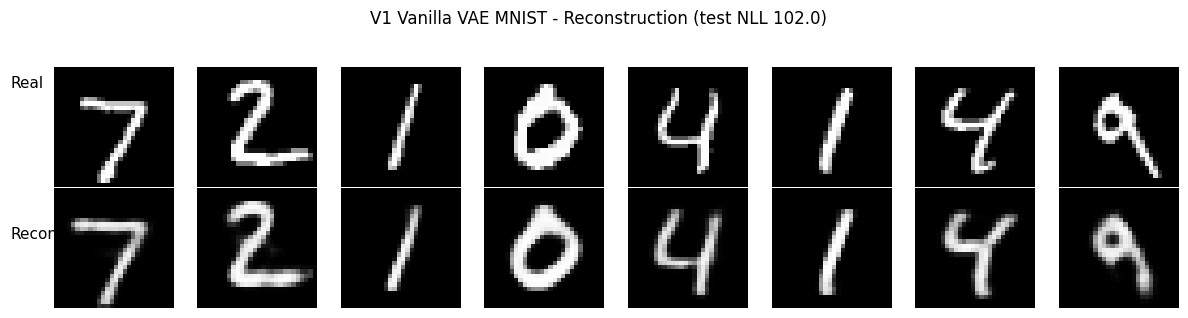

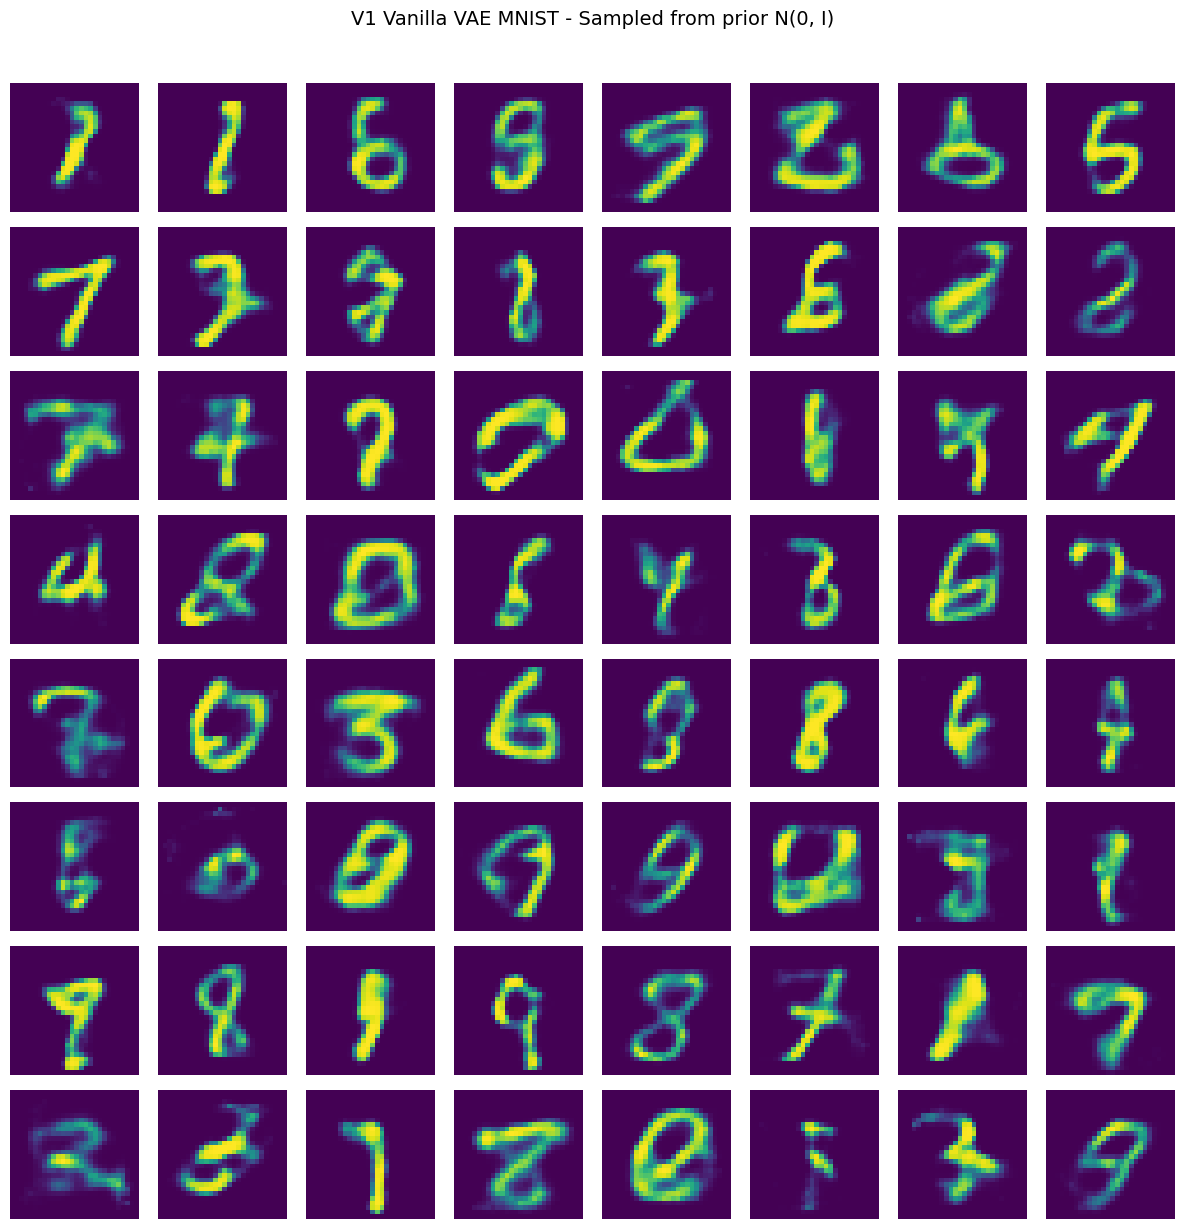

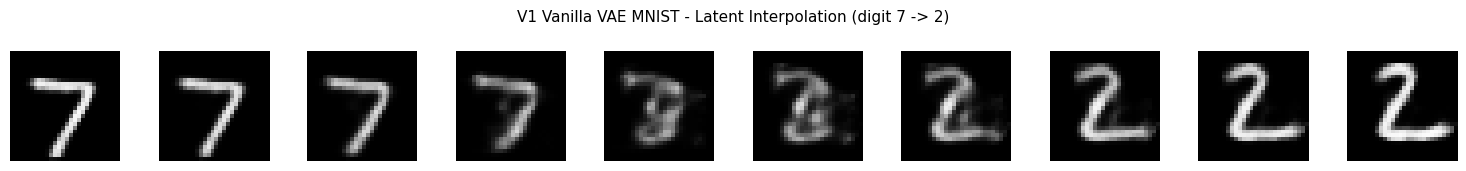

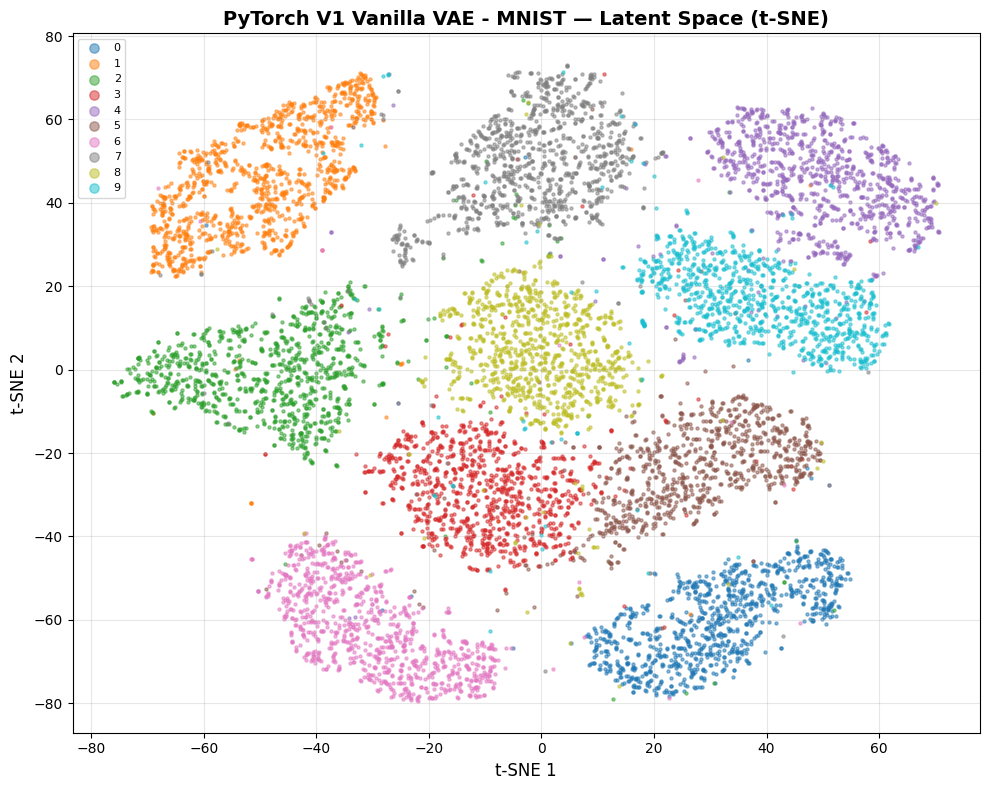

    Inference: 1.76 us/sample, 568,403 samples/sec


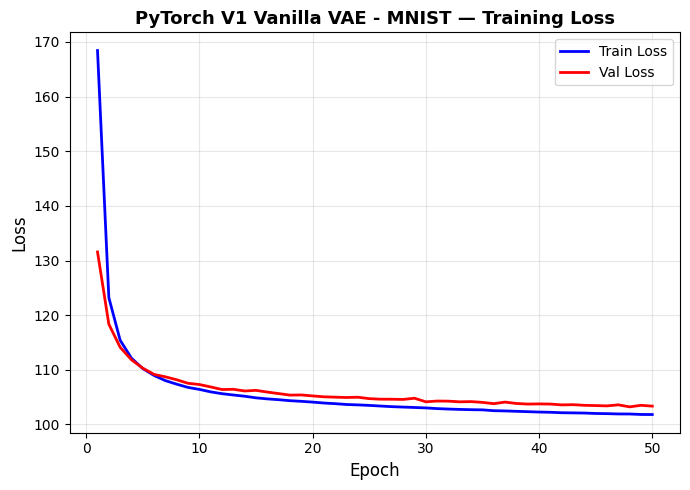


    Checkpoint: results\v1_vanilla_mnist_best.pth
    Model size: 2550.1 KB, params: 652,824


In [3]:
# Step 3: V1 Vanilla VAE on MNIST (training + test + viz)

"""
Kingma & Welling 2013 recipe: 20-dim latent, Adam(lr=1e-3), 50 epochs,
batch_size=128. Best-val-NLL snapshot for test eval.

Val carved from train (10% = 6K samples) with seeded permutation.
Test NLL reported as ELBO-derived value in nats/sample (paper ~82).
"""

# V1 MNIST hyperparameters (Kingma 2013)
V1_INPUT_DIM = 784
V1_HIDDEN_DIM = 400
V1_LATENT_DIM = 20
V1_BETA = 1.0
V1_LR = 1e-3
V1_BATCH_SIZE = 128
V1_EPOCHS = 50
V1_LOG_EVERY = 5
V1_VAL_FRAC = 0.1


# Train/val split (seeded, deterministic)
n_train_full = len(mnist_X_train)
n_val = int(V1_VAL_FRAC * n_train_full)

split_gen = torch.Generator().manual_seed(RANDOM_STATE)
perm = torch.randperm(n_train_full, generator=split_gen)
val_idx, train_idx = perm[:n_val], perm[n_val:]

train_loader = DataLoader(
    TensorDataset(mnist_X_train[train_idx]),
    batch_size=V1_BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(RANDOM_STATE),
)
val_loader = DataLoader(
    TensorDataset(mnist_X_train[val_idx]),
    batch_size=V1_BATCH_SIZE, shuffle=False,
)
test_loader = DataLoader(
    TensorDataset(mnist_X_test),
    batch_size=V1_BATCH_SIZE, shuffle=False,
)
print(f"Train: {len(train_idx):,}, Val: {len(val_idx):,}, Test: {len(mnist_X_test):,}")


# Model + optimizer
torch.manual_seed(RANDOM_STATE)
model_v1 = VAELinear(V1_INPUT_DIM, V1_HIDDEN_DIM, V1_LATENT_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model_v1.parameters(), lr=V1_LR)
num_params = sum(p.numel() for p in model_v1.parameters())
print(f"Model: VAELinear(in={V1_INPUT_DIM}, hidden={V1_HIDDEN_DIM}, latent={V1_LATENT_DIM}), "
      f"{num_params:,} params")


# Training with best-val-NLL snapshot
history = {
    'train_loss': [], 'train_recon': [], 'train_kl': [],
    'val_loss': [], 'val_recon': [], 'val_kl': [],
}
best_val = float('inf')
best_state = None

print(f"\nTraining V1 Vanilla VAE on MNIST ({V1_EPOCHS} epochs)...")
with track_performance(gpu=True) as perf:
    for epoch in range(V1_EPOCHS):
        # Train
        model_v1.train()
        tl = tr = tk = 0.0
        n = 0
        for (x,) in train_loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()
            x_recon, mu, logvar = model_v1(x)
            loss, recon, kl = vae_loss(x_recon, x, mu, logvar, beta=V1_BETA)
            loss.backward()
            optimizer.step()
            b = x.size(0)
            tl += loss.item() * b; tr += recon.item() * b; tk += kl.item() * b
            n += b
        tl /= n; tr /= n; tk /= n

        # Val
        model_v1.eval()
        vl = vr = vk = 0.0
        n = 0
        with torch.no_grad():
            for (x,) in val_loader:
                x = x.to(DEVICE)
                x_recon, mu, logvar = model_v1(x)
                loss, recon, kl = vae_loss(x_recon, x, mu, logvar, beta=V1_BETA)
                b = x.size(0)
                vl += loss.item() * b; vr += recon.item() * b; vk += kl.item() * b
                n += b
        vl /= n; vr /= n; vk /= n

        for k, v in [('train_loss', tl), ('train_recon', tr), ('train_kl', tk),
                     ('val_loss', vl), ('val_recon', vr), ('val_kl', vk)]:
            history[k].append(v)

        if vl < best_val:
            best_val = vl
            best_state = {k: v.detach().clone() for k, v in model_v1.state_dict().items()}

        if (epoch + 1) % V1_LOG_EVERY == 0 or epoch == 0:
            print(f"    ep {epoch + 1:2d}: train_loss={tl:.2f}  (recon={tr:.2f}, kl={tk:.2f}) "
                  f"| val_loss={vl:.2f}  (recon={vr:.2f}, kl={vk:.2f})")

print(f"\n    Train time: {perf['time']:.1f}s, peak GPU memory: {perf['gpu_memory']:.1f} MB")
print(f"    Best val NLL: {best_val:.2f} nats/sample")


# Test eval with best-val weights
model_v1.load_state_dict(best_state)
model_v1.eval()

test_nll = test_recon = test_kl = 0.0
n = 0
test_mus = []
test_labels = []
with torch.no_grad():
    for (x,), y in zip(test_loader, DataLoader(
            TensorDataset(mnist_y_test), batch_size=V1_BATCH_SIZE, shuffle=False)):
        x = x.to(DEVICE)
        x_recon, mu, logvar = model_v1(x)
        loss, recon, kl = vae_loss(x_recon, x, mu, logvar, beta=V1_BETA)
        b = x.size(0)
        test_nll += loss.item() * b; test_recon += recon.item() * b; test_kl += kl.item() * b
        n += b
        test_mus.append(mu.cpu())
        test_labels.append(y[0])
test_nll /= n; test_recon /= n; test_kl /= n
test_mus = torch.cat(test_mus, dim=0).numpy()
test_labels = torch.cat(test_labels, dim=0).numpy()

print(f"\n    Test NLL:       {test_nll:.2f} nats/sample  "
      f"(recon={test_recon:.2f}, kl={test_kl:.2f})")
print(f"    Kingma 2013 ref: ~82 nats")


# Visualizations: reconstruction, samples, interpolation, latent t-SNE

# 1. Reconstruction grid (inline 2x8: real on top, recon on bottom)
x_sample = mnist_X_test[:8].to(DEVICE)
with torch.no_grad():
    x_recon_sample, _, _ = model_v1(x_sample)
x_recon_sample = x_recon_sample.view(-1, 1, 28, 28).cpu()
x_sample_cpu = x_sample.cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    axes[0, i].imshow(x_sample_cpu[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(x_recon_sample[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
fig.text(0.01, 0.75, 'Real', va='center', fontsize=11)
fig.text(0.01, 0.28, 'Recon', va='center', fontsize=11)
fig.suptitle(f'V1 Vanilla VAE MNIST - Reconstruction (test NLL {test_nll:.1f})',
             fontsize=12)
plt.tight_layout(rect=[0.03, 0, 1, 0.95])
plt.savefig(RESULTS_DIR / 'v1_vanilla_mnist_recon.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Generated samples (64 draws from prior, 8x8 grid)
torch.manual_seed(RANDOM_STATE)
with torch.no_grad():
    z_prior = torch.randn(64, V1_LATENT_DIM, device=DEVICE)
    samples = model_v1.decode(z_prior).view(-1, 28, 28).cpu().numpy()
plot_generated_grid(
    samples, nrow=8,
    title='V1 Vanilla VAE MNIST - Sampled from prior N(0, I)',
    save_path=str(RESULTS_DIR / 'v1_vanilla_mnist_samples.png'),
)

# 3. Latent interpolation (encode 2 test samples, morph through 10 steps)
x1 = mnist_X_test[0:1].to(DEVICE)
x2 = mnist_X_test[1:2].to(DEVICE)
with torch.no_grad():
    mu1, _ = model_v1.encode(x1)
    mu2, _ = model_v1.encode(x2)
interp = interpolate_latent(
    lambda z: model_v1.decode(z).view(-1, 1, 28, 28),
    mu1.squeeze(0), mu2.squeeze(0), n_steps=10,
).cpu()

fig, axes = plt.subplots(1, 10, figsize=(15, 1.7))
for i in range(10):
    axes[i].imshow(interp[i, 0], cmap='gray', vmin=0, vmax=1)
    axes[i].axis('off')
fig.suptitle(
    f'V1 Vanilla VAE MNIST - Latent Interpolation '
    f'(digit {int(mnist_y_test[0])} -> {int(mnist_y_test[1])})',
    fontsize=11,
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'v1_vanilla_mnist_interp.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Latent t-SNE (entire test set, 20-dim -> 2D, colored by digit class)
plot_latent_space(
    test_mus, test_labels, MNIST_CLASS_NAMES,
    framework='PyTorch V1 Vanilla VAE - MNIST',
    method='tsne',
    save_path=str(RESULTS_DIR / 'v1_vanilla_mnist_latent_tsne.png'),
)


# Inference speed (full test set forward pass)
def _predict_v1(x_batch):
    with torch.no_grad():
        x_recon, _, _ = model_v1(x_batch.to(DEVICE))
    return x_recon.cpu()
inference_stats = track_inference(_predict_v1, mnist_X_test[:1024], n_runs=20)
print(f"    Inference: {inference_stats['per_sample_us']:.2f} us/sample, "
      f"{inference_stats['samples_per_sec']:,.0f} samples/sec")


# Log variant + checkpoint
plot_training_history(
    history,
    framework='PyTorch V1 Vanilla VAE - MNIST',
    save_path=str(RESULTS_DIR / 'v1_vanilla_mnist_history.png'),
)

model_size_bytes = sum(p.numel() * p.element_size() for p in model_v1.parameters())
mnist_variants.append({
    'variant': 'V1 Vanilla VAE',
    'dataset': 'MNIST',
    'test_nll': float(test_nll),
    'test_recon': float(test_recon),
    'test_kl': float(test_kl),
    'best_val_nll': float(best_val),
    'perf': perf,
    'inference_stats': inference_stats,
    'model_size_bytes': int(model_size_bytes),
    'num_params': int(num_params),
    'history': history,
    'hyperparams': {
        'latent_dim': V1_LATENT_DIM, 'hidden_dim': V1_HIDDEN_DIM,
        'beta': V1_BETA, 'lr': V1_LR, 'epochs': V1_EPOCHS,
    },
})

ckpt_path = RESULTS_DIR / 'v1_vanilla_mnist_best.pth'
torch.save(best_state, ckpt_path)
print(f"\n    Checkpoint: {ckpt_path}")
print(f"    Model size: {model_size_bytes / 1024:.1f} KB, params: {num_params:,}")